
# Bài tập Machine Learning — Dự đoán giá nhà Việt Nam

## Mục tiêu

1. Xây dựng **3 biểu đồ phân phối** từ `vietnam_housing_dataset.csv`.
2. Xây dựng **5 mô hình học máy** cho bài toán hồi quy.
3. Đánh giá 5 mô hình bằng **5 độ đo**: MAE, MSE, RMSE, R², MAPE và chọn mô hình tốt nhất.
4. Xuất mô hình tốt nhất để triển khai thành ứng dụng trên **điện thoại**.

### Phát biểu bài toán

Với các đặc trưng của một bất động sản (diện tích, mặt tiền, đường vào, số tầng, số phòng, vị trí, hướng nhà, pháp lý, nội thất...), dự đoán giá `Price` cho một bất động sản chưa từng xuất hiện trong tập huấn luyện.

Đây là **bài toán hồi quy (Regression)** vì biến mục tiêu `Price` là một giá trị số liên tục.

### Luồng hệ thống

`Thông tin bất động sản → Biểu diễn đặc trưng → Tiền xử lý → Mô hình ML → Giá dự đoán → Ứng dụng Mobile`


In [1]:

from pathlib import Path
import re
import time
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42


In [2]:
from IPython.display import display

DATA_PATH = r"C:\DATA\gianha.csv"

df = pd.read_csv(DATA_PATH)

print("Kích thước dataset:", df.shape)
display(df.head())

Kích thước dataset: (30229, 12)


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90



## 1. Khảo sát dữ liệu ban đầu

Dataset có 12 cột. `Price` không bị thiếu và được chọn làm **target**.

Một số đặc trưng như `Frontage`, `Access Road`, `House direction`, `Balcony direction`, `Floors`, `Bedrooms`, `Bathrooms`, `Legal status`, `Furniture state` có giá trị thiếu. Ta **không xóa toàn bộ các dòng thiếu**, mà xử lý bằng `SimpleImputer` trong pipeline:

- biến số → điền **median**;
- biến phân loại → điền **most_frequent**.

Cách làm này giúp toàn bộ tiền xử lý nằm chung trong pipeline và được tái sử dụng khi triển khai.


In [3]:

info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique()
})
display(info)
display(df.describe(include="all").T)


,dtype,missing,missing_%,nunique
Address,str,0,0.00,10265
Area,float64,0,0.00,1512
Frontage,float64,11564,38.25,407
Access Road,float64,13297,43.99,140
House direction,str,21239,70.26,8
Balcony direction,str,24983,82.65,8
Floors,float64,3603,11.92,10
Bedrooms,float64,5162,17.08,9
Bathrooms,float64,7074,23.40,9
Legal status,str,4506,14.91,2


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Address,30229,10265,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,30229.0,NaN,NaN,NaN,68.498741,48.069835,3.1,40.0,56.0,80.0,595.0
Frontage,18665.0,NaN,NaN,NaN,5.361692,4.346174,1.0,4.0,4.5,5.0,77.0
Access Road,16932.0,NaN,NaN,NaN,7.8538,7.451313,1.0,4.0,6.0,10.0,85.0
House direction,8990,8,Đông - Nam,1916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Balcony direction,5246,8,Đông - Nam,1087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floors,26626.0,NaN,NaN,NaN,3.410426,1.328897,1.0,2.0,3.0,4.0,10.0
Bedrooms,25067.0,NaN,NaN,NaN,3.51103,1.309116,1.0,3.0,3.0,4.0,9.0
Bathrooms,23155.0,NaN,NaN,NaN,3.346837,1.400181,1.0,2.0,3.0,4.0,9.0
Legal status,25723,2,Have certificate,24774,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## 2. Biểu diễn dữ liệu

Cột `Address` có số lượng giá trị khác nhau rất lớn, nên không đưa nguyên văn địa chỉ vào One-Hot Encoding.

Thay vào đó, ta trích hai đặc trưng vị trí dễ dùng khi triển khai:

- `City`: tỉnh / thành phố;
- `District`: quận / huyện / khu vực ở thành phần áp chót của địa chỉ.

Đây là **feature engineering** từ dữ liệu thô sang biểu diễn phù hợp hơn cho mô hình.


In [4]:

def normalize_address_part(value):
    value = str(value).strip()
    value = re.sub(r"[.\s]+$", "", value)
    return value

address_parts = df["Address"].astype(str).str.split(",")

df["City"] = address_parts.str[-1].map(normalize_address_part)
df["District"] = address_parts.apply(
    lambda parts: normalize_address_part(parts[-2]) if len(parts) >= 2 else "Unknown"
)

print("Số City:", df["City"].nunique())
print("Số District:", df["District"].nunique())
display(df[["Address", "City", "District"]].head())


Số City: 78
Số District: 342


,Address,City,District
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",Hưng Yên,Văn Giang
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",Hưng Yên,Văn Giang
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",Hưng Yên,Văn Giang
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",Hồ Chí Minh,Gò Vấp
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",Hồ Chí Minh,Gò Vấp



# 3. Ba biểu đồ phân phối

Ba biểu đồ được chọn để nhìn nhanh cấu trúc dữ liệu:

1. Phân phối `Price` — trực tiếp mô tả target.
2. Phân phối `Area` — một đặc trưng số quan trọng.
3. Phân phối `Bedrooms` — cho biết số lượng mẫu theo số phòng ngủ.


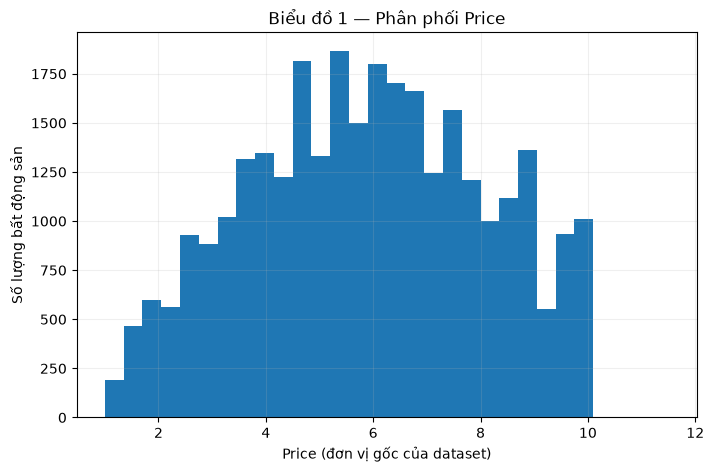

count    30229.000000
mean         5.872078
std          2.211877
min          1.000000
25%          4.200000
50%          5.900000
75%          7.500000
max         11.500000
Name: Price, dtype: float64


In [5]:

# Biểu đồ 1: Phân phối Price
plt.figure(figsize=(8, 5))
plt.hist(df["Price"].dropna(), bins=30)
plt.title("Biểu đồ 1 — Phân phối Price")
plt.xlabel("Price (đơn vị gốc của dataset)")
plt.ylabel("Số lượng bất động sản")
plt.grid(alpha=0.2)
plt.show()

print(df["Price"].describe())


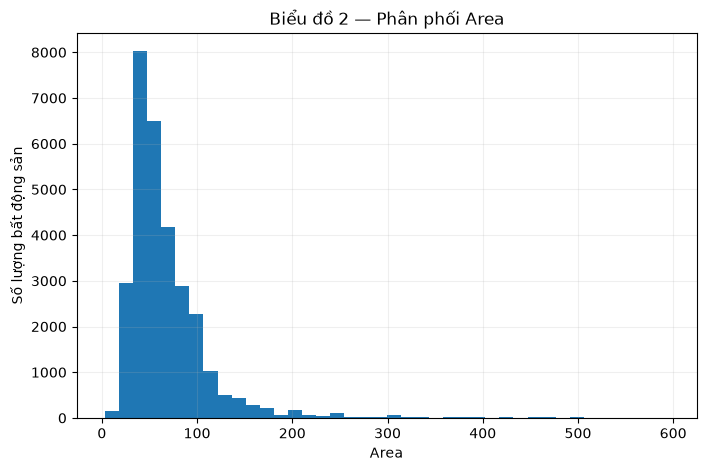

count    30229.000000
mean        68.498741
std         48.069835
min          3.100000
25%         40.000000
50%         56.000000
75%         80.000000
max        595.000000
Name: Area, dtype: float64


In [6]:

# Biểu đồ 2: Phân phối Area
plt.figure(figsize=(8, 5))
plt.hist(df["Area"].dropna(), bins=40)
plt.title("Biểu đồ 2 — Phân phối Area")
plt.xlabel("Area")
plt.ylabel("Số lượng bất động sản")
plt.grid(alpha=0.2)
plt.show()

print(df["Area"].describe())


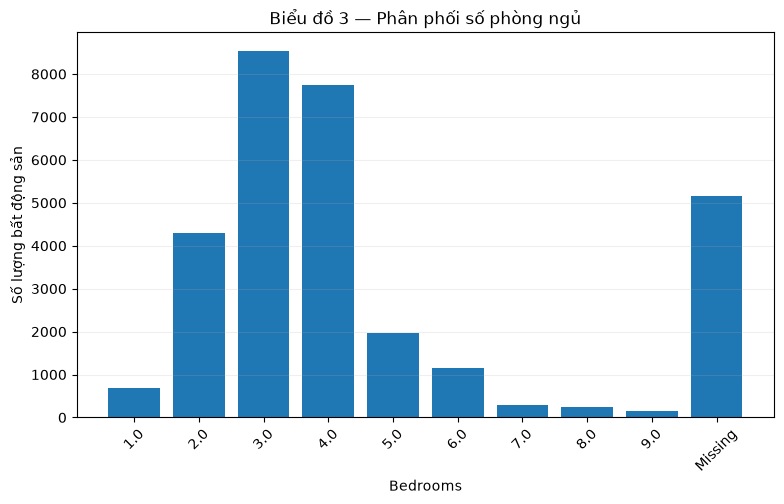

,count
Bedrooms,
1.0,684
2.0,4290
3.0,8541
4.0,7740
5.0,1964
6.0,1160
7.0,281
8.0,246
9.0,161


In [7]:

# Biểu đồ 3: Phân phối Bedrooms
bedroom_counts = (
    df["Bedrooms"]
    .fillna("Missing")
    .astype(str)
    .value_counts()
)

# Sắp xếp các giá trị số trước, Missing cuối
def bedroom_sort_key(x):
    if x == "Missing":
        return 999
    return float(x)

bedroom_counts = bedroom_counts.reindex(
    sorted(bedroom_counts.index, key=bedroom_sort_key)
)

plt.figure(figsize=(9, 5))
plt.bar(bedroom_counts.index, bedroom_counts.values)
plt.title("Biểu đồ 3 — Phân phối số phòng ngủ")
plt.xlabel("Bedrooms")
plt.ylabel("Số lượng bất động sản")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.show()

display(bedroom_counts.to_frame("count"))



# 4. Chuẩn bị dữ liệu huấn luyện

## Feature sử dụng

### Numerical
- `Area`
- `Frontage`
- `Access Road`
- `Floors`
- `Bedrooms`
- `Bathrooms`

### Categorical
- `House direction`
- `Balcony direction`
- `Legal status`
- `Furniture state`
- `City`
- `District`

## Tiền xử lý

- Numerical: `median imputation → StandardScaler`
- Categorical: `most frequent imputation → OneHotEncoder`
- Chia dữ liệu: **80% train / 20% test**
- `random_state = 42` để có thể tái lập kết quả.


In [8]:

NUMERIC_FEATURES = [
    "Area", "Frontage", "Access Road",
    "Floors", "Bedrooms", "Bathrooms"
]

CATEGORICAL_FEATURES = [
    "House direction", "Balcony direction",
    "Legal status", "Furniture state",
    "City", "District"
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "Price"

X = df[FEATURES].copy()
y = df[TARGET].copy()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=2)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, NUMERIC_FEATURES),
    ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (24183, 12)
Test : (6046, 12)



## Baseline

Baseline không được tính vào 5 mô hình chính. Nó chỉ là mốc tham chiếu để kiểm tra xem các mô hình học được có thực sự tốt hơn chiến lược rất đơn giản hay không.

Ở đây dùng `DummyRegressor(strategy="mean")`: luôn dự đoán giá trung bình của tập train.


In [9]:

baseline = Pipeline([
    ("preprocess", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

baseline_metrics = {
    "MAE": mean_absolute_error(y_test, baseline_pred),
    "MSE": mean_squared_error(y_test, baseline_pred),
    "RMSE": mean_squared_error(y_test, baseline_pred) ** 0.5,
    "R2": r2_score(y_test, baseline_pred),
    "MAPE (%)": mean_absolute_percentage_error(y_test, baseline_pred) * 100,
}

display(pd.DataFrame([baseline_metrics], index=["Baseline"]))


,MAE,MSE,RMSE,R2,MAPE (%)
Baseline,1.843751,4.876003,2.208167,-0.000018,44.434949



# 5. Xây dựng 5 mô hình học máy

Năm mô hình:

1. **Linear Regression**
2. **K-Nearest Neighbors Regressor**
3. **Decision Tree Regressor**
4. **Random Forest Regressor**
5. **Linear Support Vector Regression**

Các mô hình được đánh giá trên **cùng train/test split** và cùng pipeline tiền xử lý để so sánh công bằng.


In [10]:

models = {
    "Linear Regression": LinearRegression(),

    "KNN Regressor": KNeighborsRegressor(
        n_neighbors=7,
        weights="distance",
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=14,
        min_samples_leaf=4,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=60,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Linear SVR": LinearSVR(
        C=1.0,
        epsilon=0.1,
        random_state=RANDOM_STATE,
        max_iter=3000
    ),
}


In [11]:

results = []
trained_models = {}

for name, estimator in models.items():
    start = time.time()

    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "R2": r2_score(y_test, y_pred),
        "MAPE (%)": mean_absolute_percentage_error(y_test, y_pred) * 100,
        "Training + prediction time (s)": time.time() - start,
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(
    by=["RMSE", "MAE"],
    ascending=True
).reset_index(drop=True)

display(results_df.round(4))


,Model,MAE,MSE,RMSE,R2,MAPE (%),Training + prediction time (s)
0,Random Forest,1.0061,1.8923,1.3756,0.6119,21.0895,8.1498
1,Decision Tree,1.1720,2.4487,1.5648,0.4978,24.8164,0.7681
2,KNN Regressor,1.1677,2.4664,1.5705,0.4942,25.2105,3.4620
3,Linear Regression,1.2751,2.6858,1.6388,0.4492,27.2445,0.7150
4,Linear SVR,1.2556,2.8272,1.6814,0.4202,26.0023,0.7702


In [12]:
# ============================================================
# Experiment 2: Hyperparameter Investigation
# Question:
# How does the number of trees (n_estimators) affect
# Random Forest regression performance?
# ============================================================

rf_experiment_results = []

n_estimators_values = [20, 40, 60, 80, 100]

for n_trees in n_estimators_values:
    start = time.time()

    rf_pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=n_trees,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    rf_pipeline.fit(X_train, y_train)
    y_pred = rf_pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)

    rf_experiment_results.append({
        "n_estimators": n_trees,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "R2": r2_score(y_test, y_pred),
        "MAPE (%)": mean_absolute_percentage_error(y_test, y_pred) * 100,
        "Time (s)": time.time() - start,
    })

rf_experiment_df = pd.DataFrame(rf_experiment_results)

display(rf_experiment_df.round(4))

,n_estimators,MAE,MSE,RMSE,R2,MAPE (%),Time (s)
0,20,1.0181,1.9347,1.3909,0.6032,21.3570,3.5659
1,40,1.0110,1.9069,1.3809,0.6089,21.2178,6.0459
2,60,1.0061,1.8923,1.3756,0.6119,21.0895,9.2645
3,80,1.0046,1.8857,1.3732,0.6133,21.0368,11.9052
4,100,1.0037,1.8798,1.3710,0.6145,21.0209,15.8494


In [13]:
# ============================================================
# Experiment 3: Representation Investigation
# Question:
# Does feature standardization affect KNN regression performance?
# ============================================================

# Preprocessor có scaling — chính là preprocessor hiện tại
preprocessor_scaled = preprocessor

# Preprocessor không scaling
numeric_pipeline_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline_unscaled = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=2
    )),
])

preprocessor_unscaled = ColumnTransformer([
    ("num", numeric_pipeline_unscaled, NUMERIC_FEATURES),
    ("cat", categorical_pipeline_unscaled, CATEGORICAL_FEATURES),
])

representation_results = []

representations = {
    "Standardized": preprocessor_scaled,
    "Unscaled": preprocessor_unscaled,
}

for representation_name, current_preprocessor in representations.items():
    start = time.time()

    knn_pipeline = Pipeline([
        ("preprocess", current_preprocessor),
        ("model", KNeighborsRegressor(
            n_neighbors=7,
            weights="distance",
            n_jobs=-1
        ))
    ])

    knn_pipeline.fit(X_train, y_train)
    y_pred = knn_pipeline.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)

    representation_results.append({
        "Representation": representation_name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mse,
        "RMSE": mse ** 0.5,
        "R2": r2_score(y_test, y_pred),
        "MAPE (%)": mean_absolute_percentage_error(y_test, y_pred) * 100,
        "Time (s)": time.time() - start,
    })

representation_df = pd.DataFrame(representation_results)

display(representation_df.round(4))

,Representation,MAE,MSE,RMSE,R2,MAPE (%),Time (s)
0,Standardized,1.1677,2.4664,1.5705,0.4942,25.2105,3.4724
1,Unscaled,1.2618,2.8271,1.6814,0.4202,28.9054,2.7335


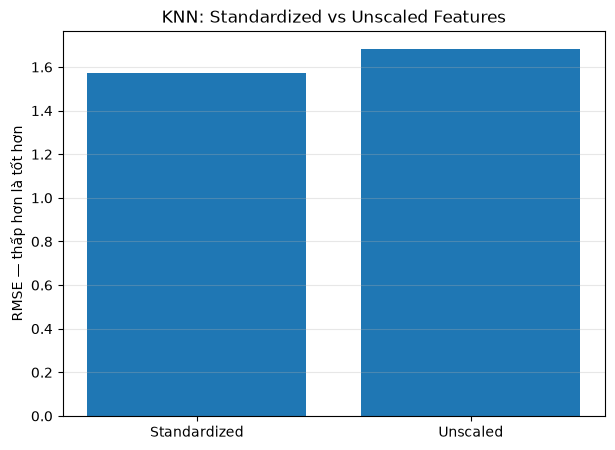

In [14]:
plt.figure(figsize=(7, 5))
plt.bar(
    representation_df["Representation"],
    representation_df["RMSE"]
)
plt.title("KNN: Standardized vs Unscaled Features")
plt.ylabel("RMSE — thấp hơn là tốt hơn")
plt.grid(axis="y", alpha=0.3)
plt.show()


# 6. Đánh giá bằng 5 độ đo

Vì đây là hồi quy nên sử dụng:

- **MAE**: sai số tuyệt đối trung bình — càng nhỏ càng tốt.
- **MSE**: bình phương sai số trung bình — phạt mạnh lỗi lớn; càng nhỏ càng tốt.
- **RMSE**: căn bậc hai của MSE — cùng đơn vị với target; càng nhỏ càng tốt.
- **R²**: tỷ lệ biến thiên của target được mô hình giải thích; càng lớn càng tốt.
- **MAPE**: sai số phần trăm tuyệt đối trung bình; càng nhỏ càng tốt.

Trong bài này, **RMSE được dùng làm tiêu chí chính** để chọn mô hình. Sau đó kiểm tra thêm MAE, R² và MAPE để tránh kết luận chỉ dựa trên một con số.


Mô hình tốt nhất theo RMSE: Random Forest


,Model,MAE,MSE,RMSE,R2,MAPE (%),Training + prediction time (s)
0,Random Forest,1.0061,1.8923,1.3756,0.6119,21.0895,8.3616


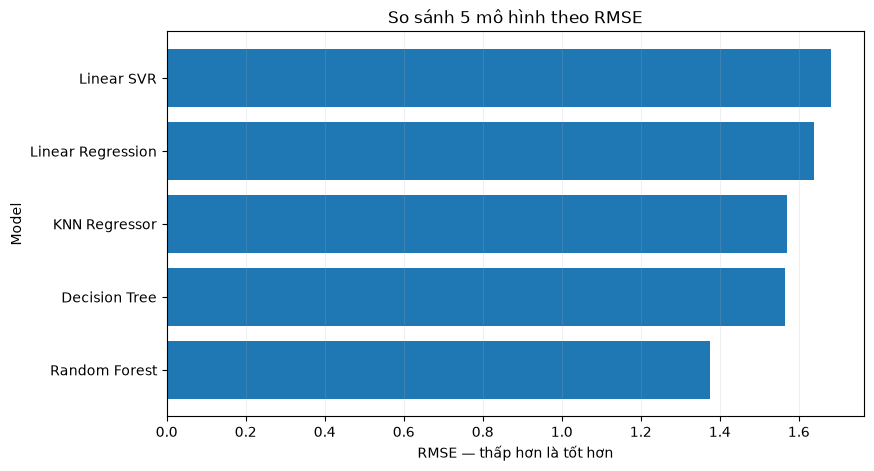

In [13]:

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Mô hình tốt nhất theo RMSE:", best_model_name)
display(results_df.iloc[[0]].round(4))

# Bảng xếp hạng trực quan theo RMSE
ranking = results_df.sort_values("RMSE", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(ranking["Model"], ranking["RMSE"])
plt.title("So sánh 5 mô hình theo RMSE")
plt.xlabel("RMSE — thấp hơn là tốt hơn")
plt.ylabel("Model")
plt.grid(axis="x", alpha=0.2)
plt.show()



## Kết luận thực nghiệm

Với cấu hình hiện tại, kết quả được chọn **không phải vì tên thuật toán**, mà dựa trên số liệu đánh giá trên tập test.

Trong lần chạy chuẩn với `random_state=42`, **Random Forest** là mô hình tốt nhất: nó có RMSE và MAE thấp nhất, đồng thời R² cao nhất trong 5 mô hình.

Điều này hợp lý với dữ liệu nhà ở vì quan hệ giữa giá và các đặc trưng như diện tích, vị trí, số tầng, số phòng... thường **phi tuyến** và có nhiều tương tác. Random Forest có khả năng mô hình hóa các quan hệ đó tốt hơn một mô hình tuyến tính đơn giản.

Tuy nhiên, R² vẫn chưa gần 1. Điều đó cho thấy dataset/representation hiện tại chưa chứa đầy đủ mọi yếu tố quyết định giá (ví dụ vị trí cực chi tiết, chất lượng công trình, thời điểm đăng tin, khoảng cách tới tiện ích...). Vì vậy không nên tuyên bố mô hình là “hoàn hảo”.


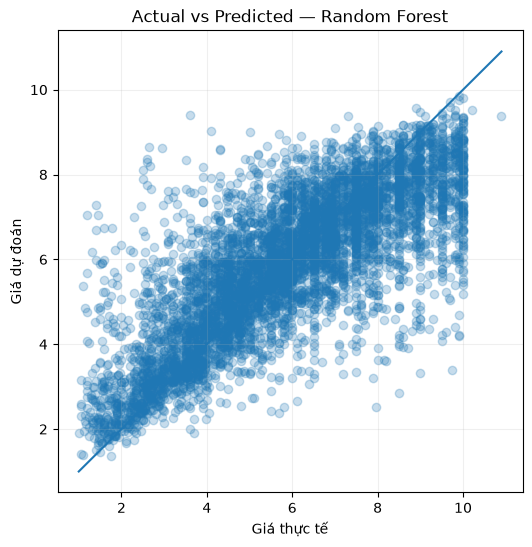

In [14]:

# Dự đoán thực tế vs dự đoán của mô hình tốt nhất
best_pred = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.25)
low = min(y_test.min(), best_pred.min())
high = max(y_test.max(), best_pred.max())
plt.plot([low, high], [low, high])
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.xlabel("Giá thực tế")
plt.ylabel("Giá dự đoán")
plt.grid(alpha=0.2)
plt.show()



# 7. Xuất mô hình tốt nhất

Ta lưu **toàn bộ pipeline**, không chỉ riêng `RandomForestRegressor`.

Điều này rất quan trọng vì khi ứng dụng Mobile gửi dữ liệu mới, dữ liệu đó phải đi qua đúng:

`Imputation → Scaling / One-Hot Encoding → Random Forest`

giống hệt lúc training.


In [16]:

MODEL_PATH = Path("best_housing_model.sav")
joblib.dump(best_model, MODEL_PATH)

print("Đã lưu:", MODEL_PATH.resolve())


Đã lưu: C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\best_housing_model.sav



# 8. Triển khai trên Mobilephone

## Kiến trúc được chọn

Với mô hình Scikit-learn, cách dễ triển khai và dễ demo nhất là:

```text
Mobile App (React Native / Expo)
        |
        | HTTP POST /predict
        v
FastAPI inference service
        |
        v
best_housing_model.joblib
        |
        v
Prediction JSON
        |
        v
Mobile hiển thị giá dự đoán
```

### Vì sao dùng API thay vì chạy `.joblib` trực tiếp trên điện thoại?

File `.joblib` chứa pipeline Python/Scikit-learn và không thể được React Native chạy trực tiếp. Đặt mô hình trong một inference service giúp:

- giữ nguyên pipeline Python đã kiểm chứng;
- Mobile chỉ cần gửi JSON và nhận kết quả;
- dễ thay model mà không cần build lại app;
- thuận tiện khi demo trên điện thoại thật.

Nếu yêu cầu của giảng viên là **offline/on-device inference**, có thể chuyển mô hình sang ONNX sau; đó là một hướng triển khai khác.



# 9. Tổng kết

Đã hoàn thành:

- 3 biểu đồ phân phối;
- feature engineering từ `Address` thành `City`, `District`;
- pipeline xử lý missing values + encoding + scaling;
- baseline;
- 5 mô hình hồi quy;
- 5 chỉ số đánh giá;
- chọn mô hình tốt nhất dựa trên bằng chứng thực nghiệm;
- lưu toàn bộ pipeline thành `best_housing_model.joblib`;
- chuẩn bị kiến trúc triển khai Mobile qua FastAPI.

> Khi viết báo cáo, cần giải thích **vì sao** mô hình tốt nhất tốt hơn, không chỉ chép bảng metric.
